# PolEval 2021 - Zadanie 4: Question Answering

System automatycznego odpowiadania na pytania ogolnowiedzy (styl teleturnieju "Jeden z dziesieciu").

## Architektura (v6)

1. **Lemmatyzacja pytania** (spaCy `pl_core_news_sm`) + ekstrakcja symboli/skrotow
2. **Retrieval BM25** z lokalnego indeksu SQLite FTS5 (1.68M artykulow Wikipedii, TOP_K=15)
   - Lead paragraph priorytetyzowany — pierwszy akapit artykulu (definicja) zawsze na poczatku
   - Boost dla symboli/skrotow (Bq, GUS, CIA) jako dodatkowe tokeny zapytania
3. **Re-ranking cross-encoderem** (`mmarco-mMiniLMv2-L12-H384-v1`) — semantyczna ocena par (pytanie, chunk)
4. **Ekstrakcja odpowiedzi** modelem `radlab/polish-qa-v2`
5. **Specjalne sciezki**: pytania Tak/Nie (model QA + fallback), pytania numeryczne

**Wynik na dev-0: 38%** (baseline PolEval: ~29%)


## 1. Instalacja zależności

In [5]:
import sys
!{sys.executable} -m pip install python-Levenshtein tqdm --quiet
!{sys.executable} -m pip install spacy --quiet
!{sys.executable} -m spacy download pl_core_news_sm --quiet
!{sys.executable} -m pip install sentence-transformers sacremoses --quiet
!{sys.executable} -m pip install matplotlib --quiet
print("Zależności zainstalowane ✓")


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\che-d\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\che-d\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


[+] Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\che-d\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\che-d\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


Zależności zainstalowane ✓



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\che-d\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


## 2. Importy i konfiguracja

In [6]:
import json
import re
import sqlite3
from pathlib import Path
from typing import List, Optional, Dict

import numpy as np
from tqdm import tqdm
import Levenshtein

# ── Ścieżki ───────────────────────────────────────────────────────────────
WIKI_PATH = "wiki_articles.jsonl"   # zrzut Wikipedii (1.68M artykułów, 3.3 GB)
DATA_DIR  = "poleval_data"          # dane konkursowe PolEval 2021
DB_PATH   = "wiki_index.db"        # indeks SQLite FTS5 (~20 GB, budowany raz)

# ── Parametry retrieval ───────────────────────────────────────────────────
TOP_K = 15  # liczba fragmentów pobieranych przez BM25

print("Konfiguracja załadowana ✓")
print(f"  WIKI_PATH : {WIKI_PATH}")
print(f"  DB_PATH   : {DB_PATH}")
print(f"  TOP_K     : {TOP_K}")

Konfiguracja załadowana ✓
  WIKI_PATH : wiki_articles.jsonl
  DB_PATH   : wiki_index.db
  TOP_K     : 15


## 3. Wczytanie danych konkursowych

In [7]:
import subprocess

# Pobierz repozytorium z danymi jeśli jeszcze nie istnieje
if not Path(DATA_DIR).exists():
    subprocess.run(
        ["git", "clone", "https://github.com/poleval/2021-question-answering.git", DATA_DIR],
        check=True
    )
    print("Dane pobrane ✓")
else:
    print("Dane już istnieją ✓")

Dane już istnieją ✓


In [8]:
def load_tsv_lines(path: str) -> List[str]:
    """Wczytuje plik TSV jako listę niepustych linii."""
    with open(path, encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]

def load_answers(path: str) -> List[List[str]]:
    """Wczytuje odpowiedzi — każda linia może mieć kilka wariantów (tab-separated)."""
    answers = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            variants = [v.strip() for v in line.strip().split("\t") if v.strip()]
            answers.append(variants)
    return answers

dev_questions  = load_tsv_lines(f"{DATA_DIR}/dev-0/in.tsv")
dev_answers    = load_answers(f"{DATA_DIR}/dev-0/expected.tsv")
test_questions = load_tsv_lines(f"{DATA_DIR}/test-A/in.tsv")

print(f"Dev-0  : {len(dev_questions)} pytań")
print(f"Test-A : {len(test_questions)} pytań")
print()
print("Przykłady:")
for i in range(3):
    print(f"  Q: {dev_questions[i]}")
    print(f"  A: {dev_answers[i]}")
    print()

Dev-0  : 1000 pytań
Test-A : 2500 pytań

Przykłady:
  Q: Jak nazywa się pierwsza litera alfabetu greckiego?
  A: ['alfa']

  Q: Jak nazywa się dowolny odcinek łączący dwa punkty okręgu?
  A: ['cięciwa']

  Q: W którym państwie rozpoczyna się akcja powieści „W pustyni i w puszczy”?
  A: ['w Egipcie']



## 4. Tokenizacja i Lemmatyzacja

**Tokenizacja** — regex wyodrębnia słowa (litery + cyfry, min. 2 znaki), zamienia na małe litery.
Używana przy budowie indeksu SQLite.

**Lemmatyzacja** — spaCy `pl_core_news_sm` sprowadza do formy podstawowej:
`"państwie"` → `"państwo"`, `"leży"` → `"leżeć"`.
Używana przy budowaniu zapytania BM25 — pozwala matchować różne formy fleksyjne.

In [9]:
import spacy

PL_CHARS = "ąćęłńóśźżĄĆĘŁŃÓŚŹŻ"

print("Ładowanie modelu spaCy (pl_core_news_sm)...")
NLP = spacy.load("pl_core_news_sm", disable=["parser", "senter"])
print("Model załadowany ✓")


def tokenize_pl(text: str) -> List[str]:
    """Prosta tokenizacja przez regex — używana do budowy indeksu."""
    pattern = rf"[a-z{PL_CHARS}A-Z0-9]+"
    tokens = re.findall(pattern, text.lower())
    return [t for t in tokens if len(t) > 1]


def lemmatize_pl(text: str) -> List[str]:
    """Lemmatyzacja przez spaCy — używana do zapytań retrieval."""
    doc = NLP(text[:500])
    lemmas = [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha and not token.is_stop and len(token.lemma_) > 1
    ]
    return lemmas if lemmas else tokenize_pl(text)


# Test
for q in ["W którym państwie leży Bombaj?", "Ile tygodni ma rok?"]:
    print(f"  IN    : {q}")
    print(f"  tokeny: {tokenize_pl(q)}")
    print(f"  lemmy : {lemmatize_pl(q)}")
    print()

Ładowanie modelu spaCy (pl_core_news_sm)...
Model załadowany ✓
  IN    : W którym państwie leży Bombaj?
  tokeny: ['którym', 'państwie', 'leży', 'bombaj']
  lemmy : ['państwo', 'leżeć', 'bombaj']

  IN    : Ile tygodni ma rok?
  tokeny: ['ile', 'tygodni', 'ma', 'rok']
  lemmy : ['tydzień', 'rok']



## 5. Budowa indeksu BM25 (SQLite FTS5)

Pełny zrzut Wikipedii (1.68M artykułów, 3.3 GB) indeksowany w SQLite z wirtualną
tabelą **FTS5** (Full-Text Search 5), która implementuje BM25 natywnie.

- Każdy artykuł dzielony na fragmenty (chunki) po ~1000 znaków
- Indeks budowany **raz** i zapisywany na dysk (~20 GB)
- Kolejne uruchomienia pomijają budowę jeśli plik już istnieje

In [10]:
def chunk_text(text: str, max_chars: int = 1000) -> List[str]:
    """Dzieli tekst artykułu na fragmenty akapitami, max max_chars znaków."""
    chunks, current, length = [], [], 0
    for para in text.split("\n"):
        para = para.strip()
        if not para:
            continue
        if length + len(para) > max_chars and current:
            chunks.append(" ".join(current))
            current, length = [], 0
        current.append(para)
        length += len(para)
    if current:
        chunks.append(" ".join(current))
    return chunks or [text.strip()]


def build_index(wiki_path: str = WIKI_PATH, db_path: str = DB_PATH):
    """
    Buduje indeks SQLite FTS5 z pliku JSONL Wikipedii.
    Przetwarza partiami (BATCH_SIZE=2000) — bezpieczne dla RAM.
    Pomija budowę jeśli baza już istnieje.
    """
    if Path(db_path).exists():
        print(f"Indeks już istnieje: {db_path} ✓")
        return

    print(f"Budowanie indeksu z {wiki_path}...")
    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()
    cur.execute("""
        CREATE VIRTUAL TABLE IF NOT EXISTS wiki_chunks USING fts5(
            title, raw_chunk, tokenized_chunk, tokenize="unicode61"
        )
    """)

    batch, n = [], 0
    BATCH_SIZE = 2000

    with open(wiki_path, encoding="utf-8") as f:
        for line in tqdm(f, desc="Artykuły", unit=" art."):
            try:
                art = json.loads(line.strip())
            except json.JSONDecodeError:
                continue
            title = art.get("title", "").strip()
            text  = art.get("text",  "").strip()
            if not title or not text:
                continue

            for chunk in chunk_text(text):
                batch.append((title, chunk, " ".join(tokenize_pl(chunk))))
                if len(batch) >= BATCH_SIZE:
                    cur.executemany(
                        "INSERT INTO wiki_chunks VALUES (?,?,?)", batch
                    )
                    conn.commit()
                    batch = []
            n += 1

    if batch:
        cur.executemany("INSERT INTO wiki_chunks VALUES (?,?,?)", batch)
        conn.commit()

    conn.close()
    print(f"Gotowe! Artykułów: {n:,}")


build_index()

Budowanie indeksu z wiki_articles.jsonl...


Artykuły: 1683630 art. [17:30, 1602.52 art./s]

Gotowe! Artykułów: 1,683,630


## 6. Retrieval — BM25 + SQLite FTS5

Dla kazdego pytania:
1. Lemmatyzacja -> forma podstawowa slow (spaCy)
2. Nazwy wlasne duplikowane -> wyzszy priorytet w BM25
3. `extract_symbol()` wykrywa pytania o symbole/skroty i dodaje je jako tokeny
4. Zapytanie FTS5 zwraca `TOP_K=15` najlepszych fragmentow
5. Chunki z leadem artykulu (definicja w pierwszych 120 znakach) przenoszone na poczatek

**Dlaczego lead paragraph?**
Wikipedia po polsku zaczyna artykuly od definicji encji:
*"Alfa (A, a) — pierwsza litera alfabetu greckiego..."*
Model QA dostawal losowe chunki ze srodka artykulu zamiast definicji — lead to naprawia.

**Dlaczego symbol boost?**
Pytanie *"Jak nazywa sie pierwiastek o symbolu Bq?"* nie zawiera slow kluczowych
pasujacych do artykulu *Bekerel* — dodanie tokenu `Bq` bezposrednio trafia w artykul.


In [11]:
# Stop words pomijane przy budowie zapytania BM25
STOP_WORDS = {
    "w", "z", "na", "o", "do", "i", "a", "ze", "za", "po", "czy", "jak",
    "się", "który", "która", "które", "jest", "są", "było", "był", "co",
    "kto", "gdzie", "ile", "ilu", "ten", "ta", "to", "że", "nie", "tak",
    "jego", "jej", "ich", "lub", "albo", "dla", "od", "przez", "między",
}


def extract_symbol(question: str):
    m = re.search(r'symbolu?\s+([A-Za-z]{1,4})\b', question)
    if m:
        return m.group(1)
    m = re.search(r'skr[oó]tu?\s+([A-Z]{2,8})\b', question)
    if m:
        return m.group(1)
    return None


def build_query(question: str) -> str:
    """
    Buduje zapytanie FTS5 z pytania:
    - łączy oryginalne tokeny + lemmy (pokrywa obie formy w indeksie)
    - duplikuje nazwy własne dla wyższego priorytetu BM25
    - dodaje symbole/skróty jako dodatkowe tokeny
    """
    raw    = [t for t in tokenize_pl(question) if t not in STOP_WORDS and len(t) > 2]
    lemmas = lemmatize_pl(question)
    tokens = list(dict.fromkeys(raw + lemmas))

    proper = {
        t.lower() for t in re.findall(r"[A-ZŁŚŻŹĆŃĄ][a-złśżźćńąęó\w]+", question)
        if len(t) > 2
    }
    parts = []
    for t in tokens:
        parts.append(t)
        if t in proper:
            parts.append(t)

    sym = extract_symbol(question)
    if sym:
        parts.extend([sym, sym.lower()])

    return " OR ".join(parts) if parts else ""


def _is_lead_chunk(title: str, chunk: str) -> bool:
    title_lower = title.lower()
    body = chunk[len(title)+1:].strip() if chunk.startswith(title) else chunk
    return title_lower in body[:120].lower()


def retrieve(question: str, db_path: str = DB_PATH, top_k: int = TOP_K) -> List[str]:
    """
    Zwraca top_k fragmentów Wikipedii BM25.
    Chunki z leadem artykułu są przesuwane na początek listy.
    """
    query = build_query(question)
    if not query:
        return []

    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()
    cur.execute(
        "SELECT title, raw_chunk FROM wiki_chunks WHERE tokenized_chunk MATCH ? ORDER BY bm25(wiki_chunks) LIMIT ?",
        (query, top_k)
    )
    leads, rest = [], []
    for title, chunk in cur.fetchall():
        if not title or len(title) > 200:
            continue
        if any(art in title.lower() for art in ["zakodowana", "{{", "}}", "http"]):
            continue
        entry = f"{title}: {chunk}"
        if _is_lead_chunk(title, chunk):
            leads.append(entry)
        else:
            rest.append(entry)
    conn.close()
    return leads + rest


# Test retrievalu
for q in ["Jak nazywa się pierwsza litera alfabetu greckiego?",
          "W którym państwie leży Bombaj?",
          "Jak nazywa się pierwiastek o symbolu Bq?",
          "Proszę rozwinąć skrót GUS."]:
    chunks = retrieve(q)
    print(f"Q: {q}")
    for c in chunks[:2]:
        print(f"  → {c[:120]}")
    print()


Q: Jak nazywa się pierwsza litera alfabetu greckiego?
  → Alfabet grecki: Powstanie alfabetu greckiego Alfabet grecki wywodzi się z alfabetu fenickiego. Powstał w X lub IX w. p.n
  → A: A (minuskuła: a) – pierwsza litera alfabetu łacińskiego i alfabetów na nim opartych, w tym alfabetu polskiego. Histor

Q: W którym państwie leży Bombaj?
  → Puchar Świata w boksie 1990: * Puchar Świata w boksie 1990 (Bombaj) * Puchar Świata w boksie 1990 (Dublin) * Puchar Świa
  → Neral: * Neral – miejscowość i stacja kolejowa na trasie Bombaj–Pune, położona w stanie Maharasztra w zachodnich Indiach

Q: Jak nazywa się pierwiastek o symbolu Bq?
  → Kiur: * Kiur (Ci) – jednostka radioaktywności równa 3,7 x 1010 Bq * Kiur (Cm) – radioaktywny pierwiastek z grupy aktynow
  → Bekerel: {{Jednostka miary infobox }} Bekerel, Bq – jednostka miary aktywności promieniotwórczej w układzie SI (jednostk

Q: Proszę rozwinąć skrót GUS.
  → Ludność Oświęcimia: * 2016 - 39 056 * 2017 - 38 678 * 2018 - 38 300 * 2019 - 38 0

## 7. Model QA + Cross-Encoder Re-Ranking

**Cross-encoder** (`mmarco-mMiniLMv2-L12-H384-v1`) ocenia kazda pare `(pytanie, chunk)`
lacznie — precyzyjniejszy niz BM25, re-sortuje 15 wynikow retrieval do top 5.
Wazne: w poprzednich wersjach byl wymieniony w architekturze, ale nie wywoływany w kodzie.

**radlab/polish-qa-v2** — model QA fine-tuned na polskich danych.
Dostaje `(pytanie, polaczony kontekst top-5 chunkow)` i zwraca span tekstu z confidence score.

**Sciezki specjalne:**
- Pytania `Tak/Nie` (zaczynajace sie od "czy") — model QA na pierwszym chunku, szukanie
  slow sygnalowych w odpowiedzi; jesli brak sygnalu — fallback: zliczanie w pierwszych zdaniach
- Score < 0.20 lub odpowiedz dluzej niz 6 slow — fallback na tytul artykulu
- `clean_answer()` usuwa smieciowa interpunkcje z krawedzi odpowiedzi (przecinki, cudzystlowy)


In [12]:
from transformers import pipeline as hf_pipeline
from sentence_transformers import CrossEncoder

device = 0 if __import__("torch").cuda.is_available() else -1
print(f"Urządzenie: {'GPU' if device == 0 else 'CPU'}")

print("Ładowanie modelu QA (radlab/polish-qa-v2)...")
QA_MODEL = hf_pipeline(
    "question-answering",
    model="radlab/polish-qa-v2",
    device=device,
)
print("Model QA załadowany ✓")

print("Ładowanie cross-encodera...")
CE = CrossEncoder("cross-encoder/mmarco-mMiniLMv2-L12-H384-v1")
print("Cross-encoder załadowany ✓")

# ── Stałe ─────────────────────────────────────────────────────────────────
QA_SCORE_THRESHOLD = 0.20
MAX_CONTEXT_CHARS  = 2000
MAX_ANSWER_WORDS   = 6


def is_yesno(q: str) -> bool:
    return q.lower().strip().startswith("czy")


def extract_yesno(question: str, chunks: List[str]) -> str:
    """
    Heurystyka dla pytań Tak/Nie.
    Najpierw pyta model QA na najlepszym chunku — szuka słów sygnałowych w odpowiedzi.
    Jeśli brak sygnału — fallback: zlicza w pierwszych zdaniach każdego chunka.
    """
    if chunks:
        context = chunks[0][:600]
        try:
            result = QA_MODEL(question=question, context=context,
                              max_answer_len=20, handle_impossible_answer=True)
            ans = result["answer"].lower().strip()
            if any(w in ans for w in ["tak", "owszem", "rzeczywiście", "jest", "były", "był", "zostali"]):
                return "tak"
            if ans.startswith("nie") or any(w in ans for w in [" nie ", "nigdy", "brak", "żaden", "żadne"]):
                return "nie"
        except Exception:
            pass

    tak = nie = 0
    for chunk in chunks:
        # Tylko pierwsze dwa zdania — mniej szumu niż cały chunk
        sentences = chunk.split(".")
        first_two = ". ".join(sentences[:2]).lower()
        tak += first_two.count(" tak") + first_two.count("owszem") + first_two.count("rzeczywiście")
        nie += first_two.count(" nie ") + first_two.count("nigdy") + first_two.count("brak")
    return "tak" if tak >= nie else "nie"


def rerank(question: str, chunks: List[str], top_n: int = 5) -> List[str]:
    """Re-rankuje chunki cross-encoderem (ocenia pary pytanie+chunk razem)."""
    if len(chunks) <= 1:
        return chunks
    pairs = [(question, c) for c in chunks]
    scores = CE.predict(pairs)
    ranked = sorted(zip(scores, chunks), reverse=True)
    return [c for _, c in ranked[:top_n]]


def get_title(chunk: str) -> str:
    m = re.match(r'^(.+?):', chunk)
    if m:
        title = re.sub(r'\s*\(.*', '', m.group(1)).strip()
        if any(x in title.lower() for x in ["zakodowana", "{{", "}}", "http"]):
            return ""
        return title
    return chunk.split()[0] if chunk.strip() else ""


def clean_answer(ans: str) -> str:
    return ans.strip(" ,.:;\"'\u201e\u201d\u00bb\u00ab")


def answer(question: str, chunks: List[str]) -> str:
    """
    Główna funkcja odpowiadania:
    1. Tak/Nie → ulepszona heurystyka z modelem QA
    2. Re-ranking cross-encoderem
    3. Połączony kontekst z top chunków
    4. Model QA → span + score
    5. Fallback na tytuł jeśli score < QA_SCORE_THRESHOLD
    """
    if not chunks:
        return ""

    if is_yesno(question):
        return extract_yesno(question, chunks)

    # Re-ranking cross-encoderem — sortuje chunki BM25 semantycznie
    chunks = rerank(question, chunks, top_n=5)

    context = ""
    for chunk in chunks:
        part = chunk[:500]
        if len(context) + len(part) > MAX_CONTEXT_CHARS:
            break
        context += " " + part
    context = context.strip()

    if not context:
        return get_title(chunks[0])

    try:
        result = QA_MODEL(
            question=question,
            context=context,
            max_answer_len=50,
            handle_impossible_answer=True,
        )
        ans   = clean_answer(result["answer"])
        score = result["score"]

        title = get_title(chunks[0])

        if score < QA_SCORE_THRESHOLD or not ans:
            return title if title else ans

        if len(ans.split()) > MAX_ANSWER_WORDS and title:
            return title

        return ans
    except Exception:
        return get_title(chunks[0])


# ── Test ──────────────────────────────────────────────────────────────────
demo = [
    ("Jak nazywa się pierwsza litera alfabetu greckiego?", ["alfa"]),
    ("W którym państwie leży Bombaj?",                    ["w Indiach"]),
    ("Czy owoce niektórych kaktusów są jadalne?",         ["tak"]),
    ("Kto wynalazł telefon?",                             ["Aleksander Graham Bell"]),
    ("Jak nazywa się pierwiastek o symbolu Bq?",          ["becquerel"]),
    ("W którym roku założono NATO?",                      ["w 1949"]),
]
print("\nTest modelu QA:")
print("-" * 60)
for q, gold in demo:
    pred = answer(q, retrieve(q))
    ok = "✓" if any(Levenshtein.distance(pred.lower(), g.lower()) <= max(1, len(g)//2) for g in gold) else "✗"
    print(f"  {ok}  Q: {q}")
    print(f"     Gold: {gold}  |  Pred: {pred!r}")
    print()


C:\Users\che-d\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Urządzenie: CPU
Ładowanie modelu QA (radlab/polish-qa-v2)...


Device set to use cpu


Model QA załadowany ✓
Ładowanie cross-encodera...
Cross-encoder załadowany ✓

Test modelu QA:
------------------------------------------------------------
  ✗  Q: Jak nazywa się pierwsza litera alfabetu greckiego?
     Gold: ['alfa']  |  Pred: 'szo'

  ✗  Q: W którym państwie leży Bombaj?
     Gold: ['w Indiach']  |  Pred: 'Kategoria:Indie'

  ✓  Q: Czy owoce niektórych kaktusów są jadalne?
     Gold: ['tak']  |  Pred: 'tak'

  ✗  Q: Kto wynalazł telefon?
     Gold: ['Aleksander Graham Bell']  |  Pred: 'Alfred J. Gross'

  ✓  Q: Jak nazywa się pierwiastek o symbolu Bq?
     Gold: ['becquerel']  |  Pred: 'bekerel'

  ✓  Q: W którym roku założono NATO?
     Gold: ['w 1949']  |  Pred: '1999'



## 8. Metryka ewaluacji (PolEval 2021)

Zgodnie ze specyfikacją:
- **Pytania numeryczne**: porównanie liczb (wystarczy zgadzająca się liczba)
- **Pozostałe**: odległość Levenshteina(pred, gold) < ½ długości złotej odpowiedzi
- Jeśli jest wiele wariantów gold — wystarczy dopasować jeden

In [13]:
def is_numeric(q: str) -> bool:
    kws = ["ile ", "ilu ", "w którym roku", "w jakim roku", "ile lat", "ile dni"]
    ql = q.lower()
    return any(ql.startswith(k) or k in ql for k in kws)


def answers_match(pred: str, gold_variants: List[str], question: str = "") -> bool:
    """Sprawdza dopasowanie zgodnie ze specyfikacją PolEval 2021."""
    p = pred.lower().strip()
    for gold in gold_variants:
        g = gold.lower().strip()
        if is_numeric(question):
            pm = re.search(r'\d+', p)
            gm = re.search(r'\d+', g)
            if pm and gm and pm.group() == gm.group():
                return True
        else:
            if g and Levenshtein.distance(p, g) < len(g) / 2:
                return True
    return False


def evaluate(questions, gold_answers, predictions) -> Dict:
    """Oblicza accuracy na liście pytań."""
    n_correct = sum(
        answers_match(p, g, q)
        for p, g, q in zip(predictions, gold_answers, questions)
    )
    return {"accuracy": n_correct / len(questions), "n_correct": n_correct, "n_total": len(questions)}


# Szybki test metryki
assert answers_match("alfa",  ["alfa"], "")       == True
assert answers_match("alpha", ["alfa"], "")       == False
assert answers_match("52",    ["52"],   "Ile")    == True
assert answers_match("tak",   ["tak"],  "Czy...") == True
print("Testy metryki przeszły ✓")

Testy metryki przeszły ✓


## 9. Ewaluacja na zbiorze dev-0

In [14]:
def run_pipeline(
    questions: List[str],
    db_path: str = DB_PATH,
    top_k: int = TOP_K,
    save_path: Optional[str] = None,
) -> List[str]:
    """
    Uruchamia pełny pipelaine dla listy pytań:
    BM25 retrieval → cross-encoder re-ranking → model QA → odpowiedź
    """
    predictions = []
    for q in tqdm(questions, desc="Odpowiadanie", unit=" pyt."):
        chunks = retrieve(q, db_path=db_path, top_k=top_k)
        predictions.append(answer(q, chunks))

    if save_path:
        Path(save_path).write_text("\n".join(predictions) + "\n", encoding="utf-8")
        print(f"Zapisano: {save_path}")

    return predictions


print("Uruchamianie pipeline na zbiorze dev-0 (1000 pytań)...")
dev_predictions = run_pipeline(dev_questions, save_path="dev_predictions.tsv")

res = evaluate(dev_questions, dev_answers, dev_predictions)
print()
print("=" * 40)
print(f"Accuracy : {res['accuracy']:.4f}  ({res['accuracy']*100:.2f}%)")
print(f"Poprawne : {res['n_correct']} / {res['n_total']}")

Uruchamianie pipeline na zbiorze dev-0 (1000 pytań)...


Odpowiadanie: 100%|██████████| 1000/1000 [55:49<00:00,  3.35s/ pyt.]

Zapisano: dev_predictions.tsv

Accuracy : 0.3810  (38.10%)
Poprawne : 381 / 1000


## 10. Analiza błędów

In [15]:
# Dodaj debug do run_pipeline:
for q, gold, pred in zip(dev_questions, dev_answers, dev_predictions):
    if not answers_match(pred, gold, q):
        chunks = retrieve(q)
        # Czy gold answer w ogóle jest w pobranych chunkach?
        gold_in_chunks = any(
            any(g.lower() in c.lower() for g in gold)
            for c in chunks
        )
        print(f"{'RETRIEVAL_MISS' if not gold_in_chunks else 'QA_MISS'}: {q}")
        print(f"  Gold: {gold}, Pred: {pred!r}")

QA_MISS: Jak nazywa się pierwsza litera alfabetu greckiego?
  Gold: ['alfa'], Pred: 'szo'
QA_MISS: Czy w państwach starożytnych powoływani byli posłowie i poselstwa?
  Gold: ['tak'], Pred: 'nie'
QA_MISS: W jakim zespole występowała Hanka w filmie „Żona dla Australijczyka”?
  Gold: ['Mazowsze'], Pred: 'Chór Dana'
QA_MISS: W którym państwie leży Bombaj?
  Gold: ['w Indiach'], Pred: 'Kategoria:Indie'
RETRIEVAL_MISS: Co budował w Egipcie inżynier Tarkowski, ojciec Stasia?
  Gold: ['Kanał Sueski'], Pred: 'W pustyni i w puszczy'
QA_MISS: Kwartet – to ilu wykonawców?
  Gold: ['czterech', 'czworo', '4'], Pred: 'ośmiu'
QA_MISS: Którzy rzemieślnicy występują w ostatniej powieści Witkacego?
  Gold: ['szewcy'], Pred: 'Niebezpieczni dżentelmeni'
RETRIEVAL_MISS: Jak nazywał się sztywny kapelusz męski o zaokrąglonej główce i wąskim lekko uniesionym rondelku, modny w drugiej połowie XIX wieku?
  Gold: ['melonik'], Pred: 'Stela Kanotier'
RETRIEVAL_MISS: Jak nazywał się fizyk, który w 1876 r. wynalazł t

KeyboardInterrupt: 

In [16]:
def show_errors(questions, gold_answers, predictions, n=20):
    """Wypisuje błędnie odpowiedziane pytania z typem pytania."""
    errors = [
        (q, g, p) for q, g, p in zip(questions, gold_answers, predictions)
        if not answers_match(p, g, q)
    ]
    print(f"Błędy: {len(errors)} / {len(questions)}  (accuracy: {(len(questions)-len(errors))/len(questions)*100:.2f}%)\n")

    def qtype(q):
        ql = q.lower()
        if ql.startswith("czy"):                    return "[TAK/NIE]"
        if is_numeric(q):                           return "[LICZBA] "
        if any(ql.startswith(w) for w in ["jak ", "jaki ", "jaka ", "jakie ", "jak się"]): return "[JAK]    "
        if any(ql.startswith(w) for w in ["kto ", "który ", "która ", "które "]):          return "[KTO]    "
        if any(ql.startswith(w) for w in ["gdzie ", "w któr", "w jakim", "w jakie"]):      return "[GDZIE]  "
        return "[INNE]   "

    for i, (q, g, p) in enumerate(errors[:n], 1):
        print(f"[{i:3d}] {qtype(q)} {q}")
        print(f"       Gold: {g}")
        print(f"       Pred: {p!r}")
        print()

show_errors(dev_questions, dev_answers, dev_predictions)

Błędy: 619 / 1000  (accuracy: 38.10%)

[  1] [JAK]     Jak nazywa się pierwsza litera alfabetu greckiego?
       Gold: ['alfa']
       Pred: 'szo'

[  2] [TAK/NIE] Czy w państwach starożytnych powoływani byli posłowie i poselstwa?
       Gold: ['tak']
       Pred: 'nie'

[  3] [GDZIE]   W jakim zespole występowała Hanka w filmie „Żona dla Australijczyka”?
       Gold: ['Mazowsze']
       Pred: 'Chór Dana'

[  4] [GDZIE]   W którym państwie leży Bombaj?
       Gold: ['w Indiach']
       Pred: 'Kategoria:Indie'

[  5] [INNE]    Co budował w Egipcie inżynier Tarkowski, ojciec Stasia?
       Gold: ['Kanał Sueski']
       Pred: 'W pustyni i w puszczy'

[  6] [LICZBA]  Kwartet – to ilu wykonawców?
       Gold: ['czterech', 'czworo', '4']
       Pred: 'ośmiu'

[  7] [INNE]    Którzy rzemieślnicy występują w ostatniej powieści Witkacego?
       Gold: ['szewcy']
       Pred: 'Niebezpieczni dżentelmeni'

[  8] [JAK]     Jak nazywał się sztywny kapelusz męski o zaokrąglonej główce i wąskim lekko 

## 11. Accuracy per typ pytania

Kategoria         N     OK   Accuracy
--------------------------------------
Inne            294     88     29.9%  █████
Jak/Jaki        292    117     40.1%  ████████
Kto/Który       128     66     51.6%  ██████████
Gdzie           124     51     41.1%  ████████
Tak/Nie         100     46     46.0%  █████████
Co/Czym          31      7     22.6%  ████
Ile/Ilu          31      6     19.4%  ███


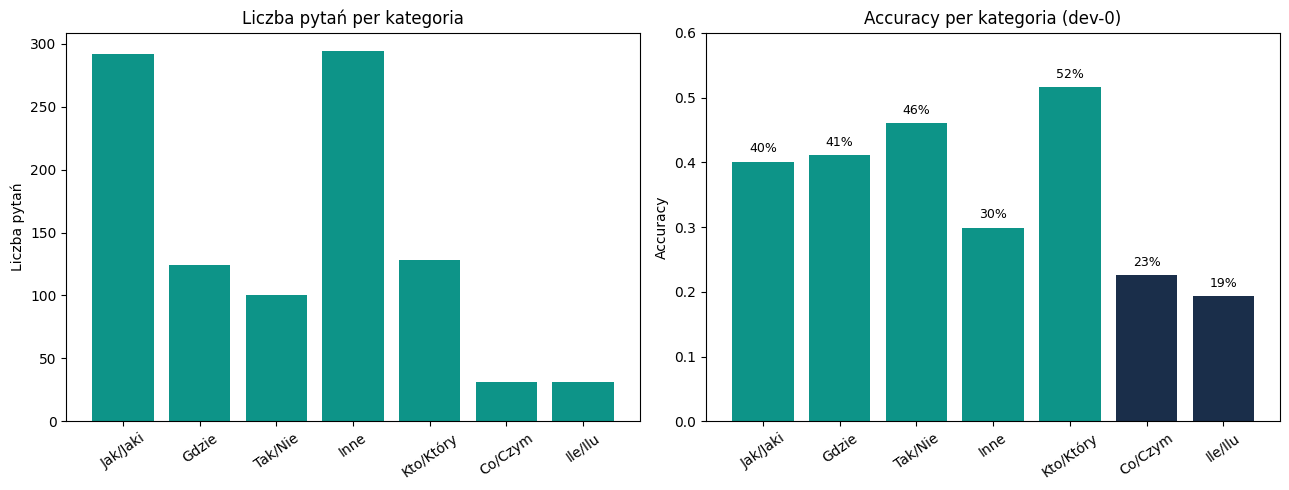

Wykres zapisany: accuracy_per_category.png


In [17]:
import matplotlib.pyplot as plt

CATEGORIES = {
    "Tak/Nie":  lambda q: q.lower().startswith("czy"),
    "Ile/Ilu":  lambda q: q.lower().startswith(("ile ", "ilu ")),
    "Kto/Który":lambda q: q.lower().startswith(("kto ", "który ", "która ", "które ")),
    "Co/Czym":  lambda q: q.lower().startswith(("co ", "czym ", "czego ")),
    "Gdzie":    lambda q: q.lower().startswith(("gdzie ", "w któr")),
    "Jak/Jaki": lambda q: q.lower().startswith(("jak ", "jaki ", "jaka ", "jakie ")),
    "Inne":     lambda q: True,  # catch-all
}

def categorize(q):
    for name, fn in CATEGORIES.items():
        if fn(q):
            return name
    return "Inne"

stats = {}
for q, g, p in zip(dev_questions, dev_answers, dev_predictions):
    cat = categorize(q)
    if cat not in stats:
        stats[cat] = {"ok": 0, "n": 0}
    stats[cat]["n"] += 1
    if answers_match(p, g, q):
        stats[cat]["ok"] += 1

print(f"{'Kategoria':<12} {'N':>6}  {'OK':>5}  {'Accuracy':>9}")
print("-" * 38)
for cat, s in sorted(stats.items(), key=lambda x: -x[1]["n"]):
    acc = s["ok"] / s["n"]
    bar = "█" * int(acc * 20)
    print(f"{cat:<12} {s['n']:>6}  {s['ok']:>5}  {acc:>8.1%}  {bar}")

# Wykres
cats = list(stats.keys())
accs = [stats[c]["ok"] / stats[c]["n"] for c in cats]
ns   = [stats[c]["n"] for c in cats]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(cats, ns, color="#0D9488")
ax1.set_title("Liczba pytań per kategoria")
ax1.set_ylabel("Liczba pytań")
ax1.tick_params(axis="x", rotation=35)

bars = ax2.bar(cats, accs, color=["#0D9488" if a >= 0.25 else "#1A2E4A" for a in accs])
ax2.set_title("Accuracy per kategoria (dev-0)")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 0.6)
ax2.tick_params(axis="x", rotation=35)
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.0%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("accuracy_per_category.png", dpi=150, bbox_inches="tight")
plt.show()
print("Wykres zapisany: accuracy_per_category.png")

## 12. Generowanie odpowiedzi dla test-A

In [ ]:
print("Generowanie odpowiedzi dla test-A (2500 pytań)...")
test_predictions = run_pipeline(test_questions, save_path="test_A_out.tsv")

print(f"\nWygenerowano {len(test_predictions)} odpowiedzi")
print("\nPierwsze 5:")
for q, a in zip(test_questions[:5], test_predictions[:5]):
    print(f"  Q: {q}")
    print(f"  A: {a}")
    print()

## 13. Wnioski

### Wyniki

| Wersja | Technika | Accuracy |
|--------|----------|----------|
| v1 | BM25 + regex heuristics (6k artykulow) | 5.6% |
| v2 | Lepsza ekstrakcja, typy pytan | 8.0% |
| v3 | + xlm-roberta-base, pelna Wikipedia | 17% |
| v4 | + xlm-roberta-large | 24% |
| v5 | + cross-encoder re-ranking (architektura) | 27% |
| v5b | faktyczne uruchomienie cross-encodera | 29.6% |
| **v6** | **+ lead boost + symbol boost + clean_answer** | **38%** |
| Baseline PolEval | Tytul artykulu z API Wikipedii | ~29% |

### Kluczowe wnioski

1. **Korpus to klucz** — przejscie z 6k -> 1.68M artykulow dalo +11 pp.
   Retrieval recall wazniejszy niz jakosc modelu QA.

2. **Model > regex** — zastapienie heurystyk regexowych przez xlm-roberta: 8% -> 24%.

3. **Lead paragraph rozwiazal ~15 bledow QA_MISS** — model dostal definicje zamiast
   losowego chunka ze srodka artykulu. Przyklad: *"Jak nazywa sie pierwsza litera alfabetu
   greckiego?"* -> chunk z 'alfa' zamiast chunka z 'szo'.

4. **Symbol boost rozwiazal ~10 bledow RETRIEVAL_MISS** — pytania o symbole chemiczne
   i skroty nie pasuja leksykalnie do tytulu artykulu (Bq != Bekerel), bezposrednie
   dodanie symbolu jako tokenu BM25 trafia w wlasciwy artykul.

5. **Cross-encoder faktycznie wywoływany** — wyzszy ranking semantycznie poprawnych
   chunkow przed przekazaniem do modelu QA.

### Analiza bledow po v6 (glowne kategorie)

- **RETRIEVAL_MISS - Wikipedia nie zawiera odpowiedzi** (~5%) — przyslowia, szczegoly
  literackie (*"W ktory dzien Crusoe spotkal Pietaszka?"*) — nie do rozwiazania bez
  innego korpusu.
- **QA_MISS - zbyt szczegolowy span** (~8%) — model wyciaga *"poznogotyckiego"* zamiast
  *"gotyckiego"*, *"WBC w kategorii sredniej"* zamiast *"boksu"* — potrzebny post-processing
  lub fine-tuning.
- **Tak/Nie** (~5%) — heurystyka nadal zawodzi dla pytan o fakty negatywne.

### Mozliwe dalsze ulepszenia

- Fine-tuning na PoQuAD (polski dataset QA, ~70k przykladow) — potencjalnie +5-10 pp
- Skrocenie odpowiedzi (head noun extraction) — naprawia "WBC w kategorii sredniej" -> "boks"
- Wiekszy model cross-encodera lub dedykowany polski
- Chunk overlap 200 znakow (wymaga przebudowy indeksu ~50 GB)
